https://www.kaggle.com/datasets/sumedh1507/blood-donor-dataset/data

# Previsão da disponibilidade de doadores de sangue


# Sobre o conjunto de dados
📄 **Descrição do conjunto de dados**
Este conjunto de dados contém registros de doadores de sangue, com o objetivo de prever se um doador está atualmente disponível para doação. Inclui uma combinação de atributos demográficos, médicos e de histórico de doação.

Cada linha representa um único doador e fornece recursos como:

Grupo sanguíneo

Idade, Peso, Hemoglobina

Última data de doação

Número de doações

Disponibilidade (variável alvo)

A disponibilidade da variável alvo indica se o doador provavelmente está disponível para doação no momento da consulta.

Este conjunto de dados é ideal para criar modelos de classificação, explorar análises de assistência médica e demonstrar como o aprendizado de máquina pode dar suporte ao gerenciamento de bancos de sangue e à tomada de decisões em saúde pública.

# 📑 Descritores de Coluna

Nome da coluna	Descrição
ID do doador	Identificador único atribuído a cada doador
grupo sanguíneo	Tipo sanguíneo do doador (por exemplo, A+, B-, O+, AB-)
idade	Idade do doador em anos
peso	Peso do doador em quilogramas
hemoglobina	Nível de hemoglobina (g/dL), usado para avaliar a elegibilidade do doador
última_doação	Data da última doação do doador
num_doações	Número total de doações anteriores bem-sucedidas
gênero	Sexo do doador (por exemplo, masculino, feminino, outro)
disponibilidade	Variável alvo – se o doador está atualmente disponível para doar

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import xgboost as xgb

df_blood = pd.read_csv('blood_donor_dataset.csv')

In [2]:
#Informações
df_blood.info()
df_blood.head()
df_blood.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   donor_id                     10000 non-null  object
 1   name                         10000 non-null  object
 2   email                        10000 non-null  object
 3   password                     10000 non-null  object
 4   contact_number               10000 non-null  object
 5   city                         10000 non-null  object
 6   blood_group                  10000 non-null  object
 7   availability                 10000 non-null  object
 8   months_since_first_donation  10000 non-null  int64 
 9   number_of_donation           10000 non-null  int64 
 10  pints_donated                10000 non-null  int64 
 11  created_at                   10000 non-null  object
dtypes: int64(3), object(9)
memory usage: 937.6+ KB


,months_since_first_donation,number_of_donation,pints_donated
count,10000.000000,10000.000000,10000.000000
mean,59.953100,25.128200,37.614000
std,34.911379,14.654195,26.334072
min,0.000000,0.000000,0.000000
25%,30.000000,12.000000,16.000000
50%,60.000000,26.000000,34.000000
75%,90.000000,38.000000,50.000000
max,120.000000,50.000000,100.000000


In [3]:
df_blood

,donor_id,name,email,password,contact_number,city,blood_group,availability,months_since_first_donation,number_of_donation,pints_donated,created_at
0,1b8b4c828a,Norma Fisher,ysullivan@yahoo.com,P5hX6Syg*A,+61 461706749,Hobart,A+,No,65,31,62,2017-03-17
1,a6a3f7fe55,Eugene Bowman,hramos@brown-sellers.com,b6Wq6Cqz@5,+61 450709944,Darwin,AB-,Yes,64,8,16,2016-11-11
2,cee6478144,Sheri Bolton DDS,jasmine85@hotmail.com,$9RB51m#s7,+61 428756361,Melbourne,AB+,Yes,39,6,6,2022-02-25
3,5986bc55f9,Kelly Boyd,pattylawrence@riley-hayes.com,@5Tdg(4kCm,+61 454318320,Darwin,A-,No,55,20,20,2025-04-04
4,93246afe6c,Taylor Guzman,martinezjacob@wilson.com,x!)9Ag@J*7,+61 484158472,Darwin,O-,No,7,35,35,2022-11-30
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,700aeefbf1,Bradley Pham,jessica49@turner.com,^@d9SMqSa1,+61 443906132,Hobart,A+,Yes,66,42,42,2019-02-11
9996,487b342992,Richard Harris,megan51@gmail.com,D1OAZg5i)g,+61 443105290,Hobart,O-,No,65,14,28,2025-02-18
9997,ddf4485d67,Autumn Kim,curtisdonald@wilson.info,3wU2fua(#7,+61 472390553,Hobart,B+,No,57,16,32,2019-04-29
9998,4256813ba5,Janice Murphy,jenningscristian@hotmail.com,&8zDeXl)b(,+61 492945719,Perth,AB-,Yes,79,23,46,2022-08-23


In [4]:
#Distribuição da variável alvo ('availability')
print("Contagem da variável 'availability':")
print(df_blood['availability'].value_counts())

Contagem da variável 'availability':
availability
Yes    5085
No     4915
Name: count, dtype: int64


In [5]:
#Converter a coluna 'created_at' para o tipo datetime
df_blood['created_at'] = pd.to_datetime(df_blood['created_at'])

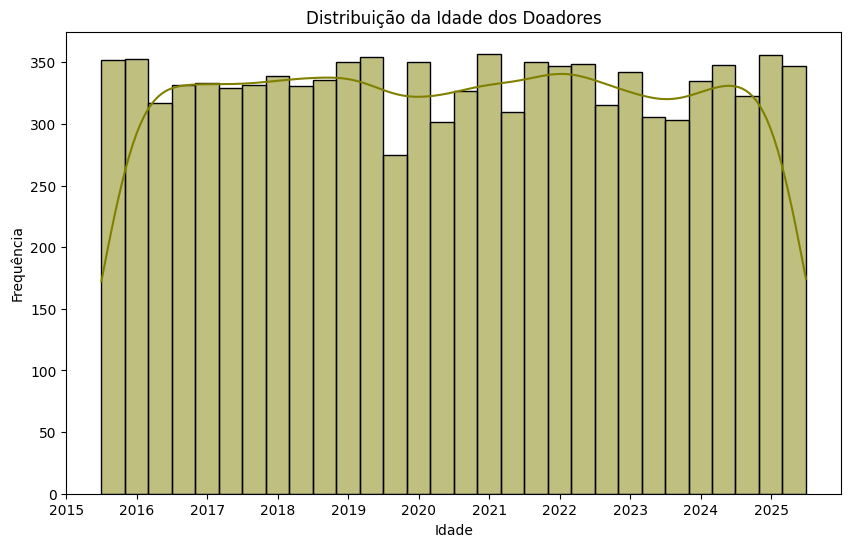

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df_blood['created_at'], bins=30, kde=True, color='olive')
plt.title('Distribuição da Idade dos Doadores')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

A distribuição de idade dos doadores é bastante homogênea, com a maioria das faixas etárias contribuindo de forma similar para as doações. As variações observadas ao longo do tempo podem ser atribuídas a fatores específicos de cada ano, reforçando a necessidade de estratégias contínuas para manter e expandir a base de doadores.

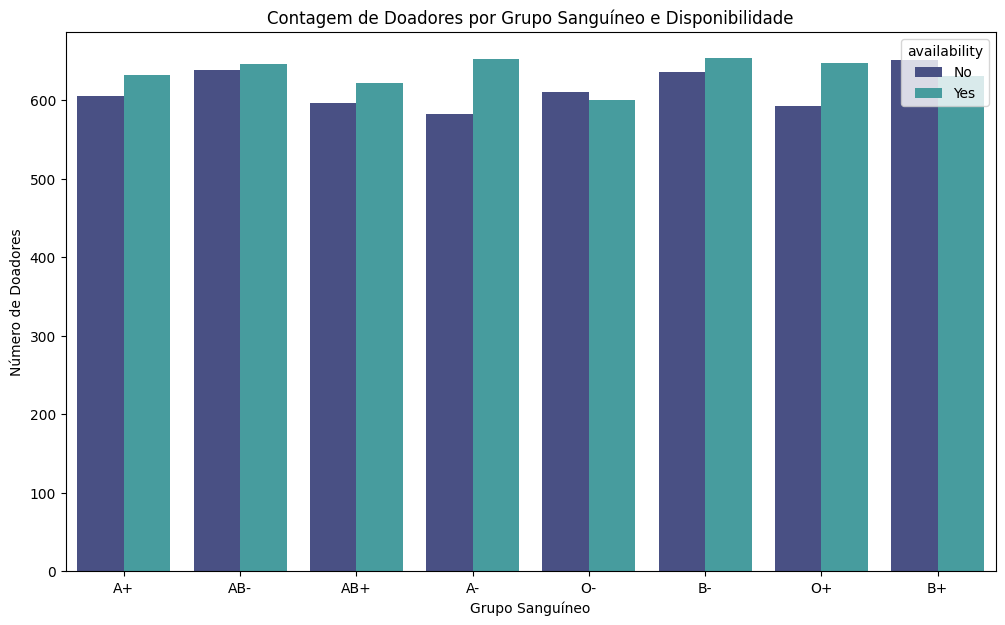

In [7]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df_blood, x='blood_group', hue='availability', palette='mako')
plt.title('Contagem de Doadores por Grupo Sanguíneo e Disponibilidade')
plt.xlabel('Grupo Sanguíneo')
plt.ylabel('Número de Doadores')
plt.show()

**Grupos com Maior Disponibilidade:** Os grupos sanguíneos AB-, A-, O+ e B+ mostram uma diferença notável entre doadores disponíveis e não disponíveis, com o número de doadores "Sim" superando os doadores "Não" em mais de 50. Isso destaca a alta disponibilidade desses grupos específicos, o que pode ser estratégico para futuras campanhas.

**Grupos com Menor Diferença:** Os grupos A+ e O- apresentam uma diferença menor entre doadores disponíveis e não disponíveis, embora a categoria "Sim" ainda seja predominante. Isso pode indicar uma oportunidade para campanhas de conscientização focadas em aumentar a disponibilidade desses doadores.

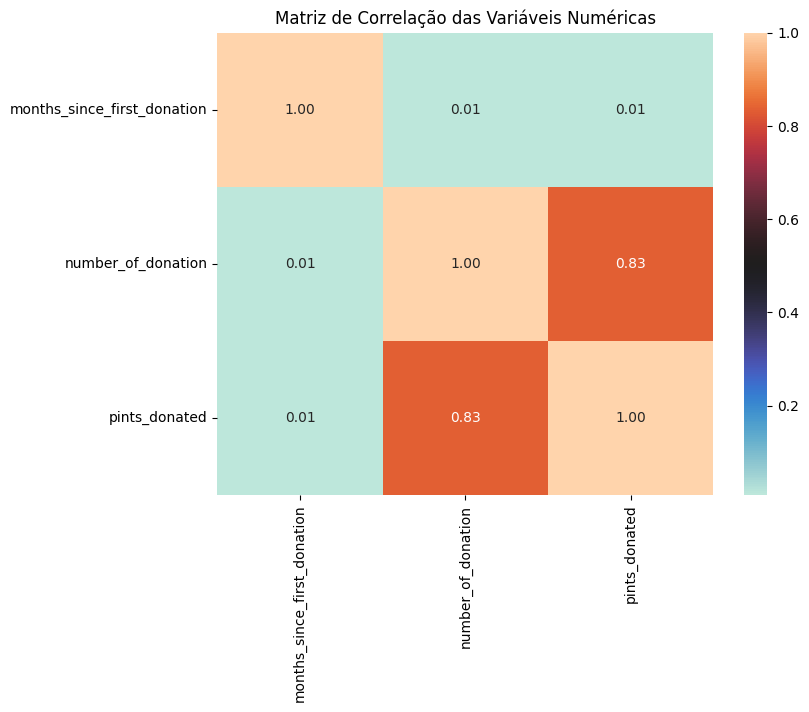

In [8]:
numeric_cols = ['months_since_first_donation', 'number_of_donation', 'pints_donated']
correlation_matrix = df_blood[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='icefire', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

Demonstra uma relação direta entre a quantidade de doações e a quantidade de sangue doado, mas não mostra uma relação entre o tempo desde a primeira doação e a quantidade de vezes que a pessoa doou.

In [9]:
#Identificação irrelevantes para o modelo
df_model = df_blood.drop(columns=['donor_id', 'name', 'email', 'password', 'contact_number', 'created_at'])

#Variável alvo 'availability' (sim = 1, não = 0)
le = LabelEncoder()
df_model['availability'] = le.fit_transform(df_model['availability'])

df_model = pd.get_dummies(df_model, columns=['city', 'blood_group'], drop_first=True)

X = df_model.drop('availability', axis=1)
y = df_model['availability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

In [11]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Avaliação do Modelo de Regressão Logística")
print(f"Acurácia: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_lr))

Avaliação do Modelo de Regressão Logística
Acurácia: 0.5110
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.51      0.36      0.42       992
           1       0.51      0.66      0.58      1008

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.51      0.51      0.50      2000



In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np

In [13]:
#Rede Neural
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Avaliação da Rede Neural")
print(f"Acurácia no conjunto de teste: {accuracy:.4f}")

Epoch 1/20


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5113 - loss: 0.7241 - val_accuracy: 0.5075 - val_loss: 0.6938
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5086 - loss: 0.7044 - val_accuracy: 0.5206 - val_loss: 0.6930
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4988 - loss: 0.7016 - val_accuracy: 0.4931 - val_loss: 0.6935
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5070 - loss: 0.6970 - val_accuracy: 0.4969 - val_loss: 0.6933
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5066 - loss: 0.6946 - val_accuracy: 0.5069 - val_loss: 0.6934
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5075 - loss: 0.6952 - val_accuracy: 0.5025 - val_loss: 0.6933
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5038 - loss: 0.6942 - val_accuracy: 0.4925 - val_loss: 0.6934
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5166 - loss: 0.6938 - val_accuracy: 0.4963 - val_

In [14]:
y_pred_nn_prob = model.predict(X_test_scaled)
y_pred_nn = np.round(y_pred_nn_prob).flatten()

print("Relatório de Classificação da Rede Neural:")
print(classification_report(y_test, y_pred_nn))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Relatório de Classificação da Rede Neural:
              precision    recall  f1-score   support

           0       0.41      0.08      0.13       992
           1       0.50      0.89      0.64      1008

    accuracy                           0.49      2000
   macro avg       0.45      0.48      0.38      2000
weighted avg       0.45      0.49      0.39      2000



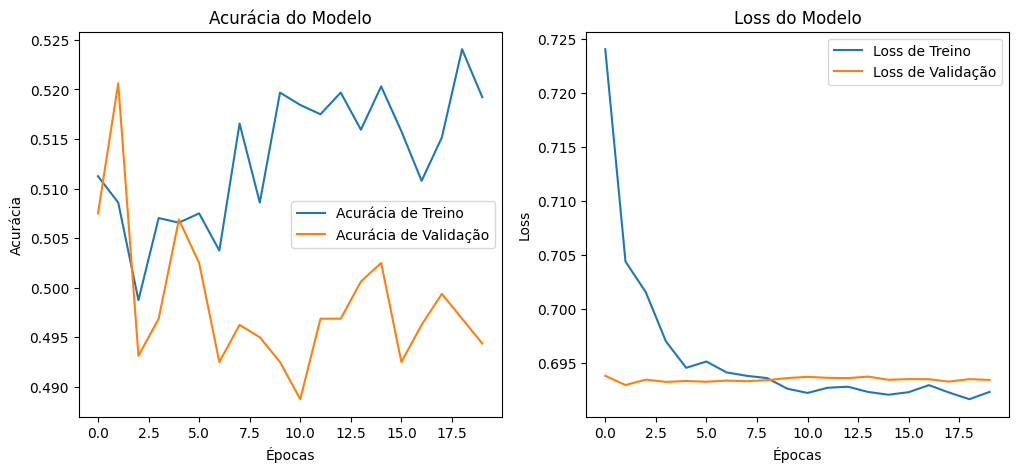

In [15]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Acurácia do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss de Treino')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.title('Loss do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

A máquina apresentado tem um desempenho insatisfatório. Os resultados sugerem um forte caso de sobreajuste (overfitting), onde o modelo memoriza os dados de treino em vez de aprender a lógica subjacente. Isso é evidenciado pela acurácia de treino significativamente maior do que a de validação e pela grande instabilidade das curvas de acurácia. A perda, embora estável, não aponta para uma melhora significativa ao longo das épocas.

In [16]:
#Novas features
df_blood['registration_month'] = df_blood['created_at'].dt.month
df_blood['registration_year'] = df_blood['created_at'].dt.year
df_blood['registration_day_of_week'] = df_blood['created_at'].dt.dayofweek

C:\Users\Usuário\AppData\Local\Temp\ipykernel_8428\302302619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_blood, x='registration_year', palette='mako')


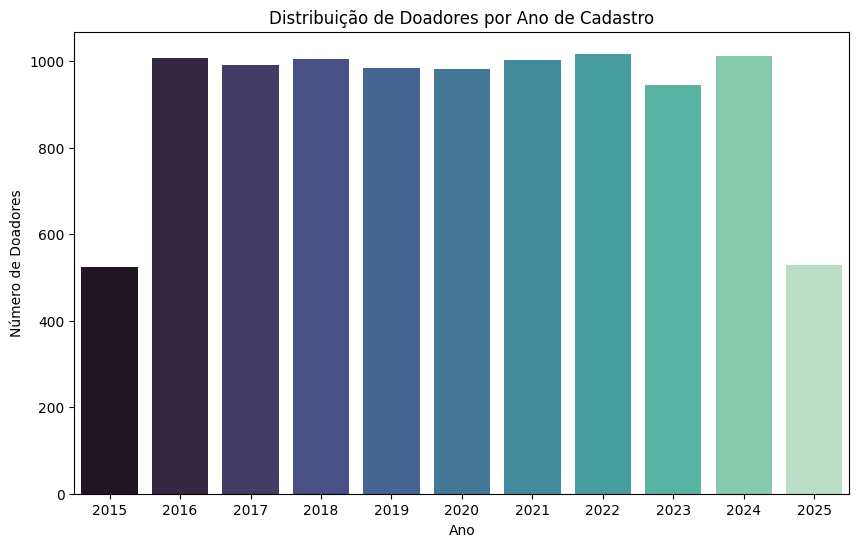

In [17]:
#Ano de cadastro
plt.figure(figsize=(10, 6))
sns.countplot(data=df_blood, x='registration_year', palette='mako')
plt.title('Distribuição de Doadores por Ano de Cadastro')
plt.xlabel('Ano')
plt.ylabel('Número de Doadores')
plt.show()

A captação de novos doadores foi muito forte e consistente entre 2016 e 2024. A estabilidade no número de cadastros anuais demonstra a eficácia das estratégias de atração de doadores. A queda em 2025, no entanto, deve ser analisada com cuidado, pois pode ser um dado parcial.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_8428\3209049114.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='availability', y='number_of_donation', data=df_blood, palette='mako')


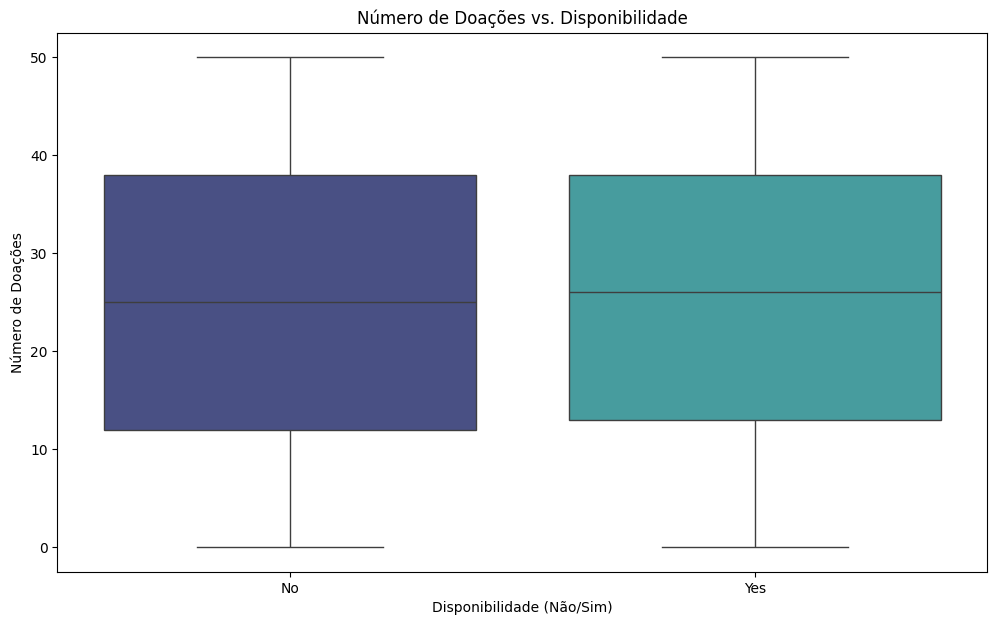

In [18]:
#Número de doações e disponibilidade
plt.figure(figsize=(12, 7))
sns.boxplot(x='availability', y='number_of_donation', data=df_blood, palette='mako')
plt.title('Número de Doações vs. Disponibilidade')
plt.xlabel('Disponibilidade (Não/Sim)')
plt.ylabel('Número de Doações')
plt.show()

O número de doações passadas de um indivíduo não é um fator determinante para sua disponibilidade futura. As razões para a disponibilidade ou não de um doador devem ser exploradas em outras variáveis, como a idade, o tempo desde a última doação, ou outros fatores que não são visíveis neste gráfico.

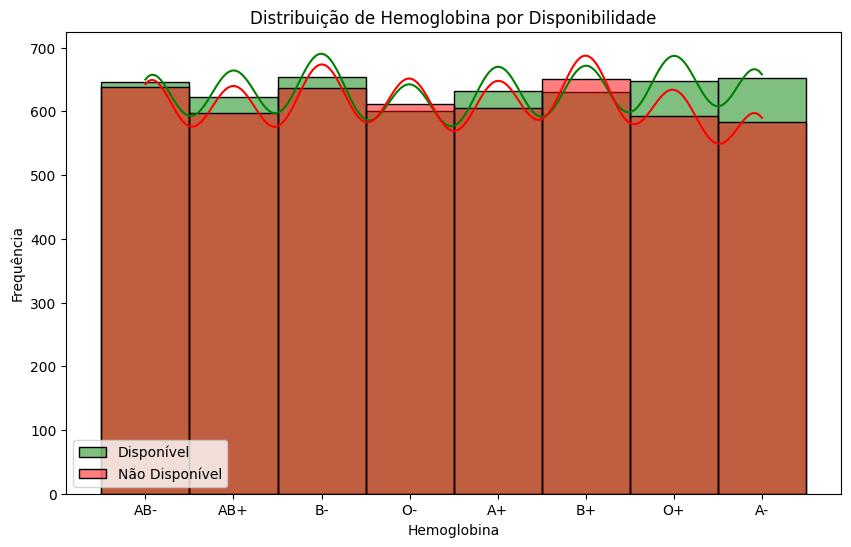

In [19]:
#Hemoglobina vs. Disponibilidade
plt.figure(figsize=(10, 6))
sns.histplot(df_blood[df_blood['availability'] == 'Yes']['blood_group'], color='green', kde=True, label='Disponível')
sns.histplot(df_blood[df_blood['availability'] == 'No']['blood_group'], color='red', kde=True, label='Não Disponível')
plt.title('Distribuição de Hemoglobina por Disponibilidade')
plt.xlabel('Hemoglobina')
plt.ylabel('Frequência')
plt.legend()
plt.show()

A disponibilidade do doador não parece ter uma relação direta com o nível de hemoglobina. Ambos os grupos, "disponível" e "não disponível", têm distribuições de frequência semelhantes em relação à hemoglobina, o que indica que outros fatores, como saúde geral, histórico de doações ou motivos pessoais, podem influenciar mais a disponibilidade para doação.

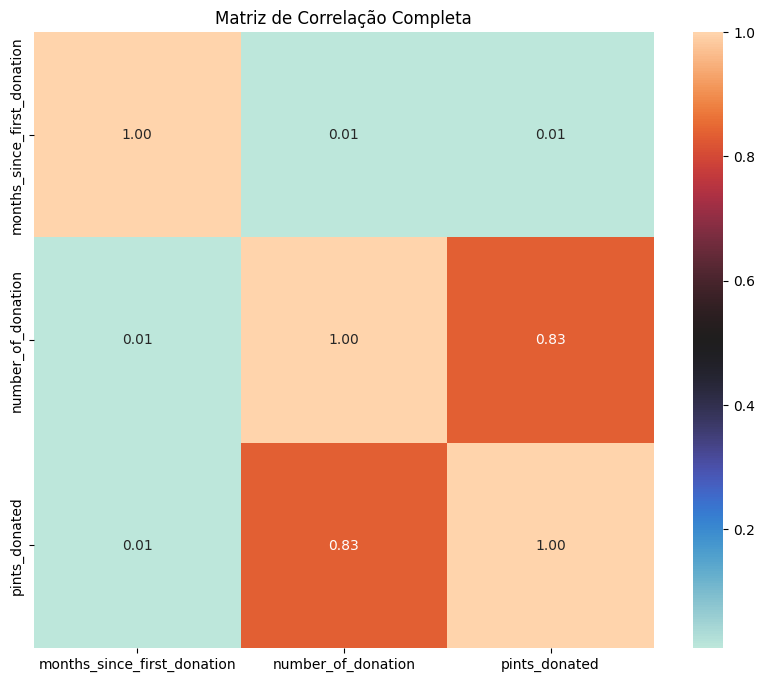

In [20]:
numeric_cols = ['months_since_first_donation', 'number_of_donation', 'pints_donated']
correlation_matrix = df_blood[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='icefire', fmt=".2f")
plt.title('Matriz de Correlação Completa')
plt.show()

Uma relação direta entre a quantidade de doações e a quantidade de sangue doado, mas não mostra uma relação entre o tempo desde a primeira doação e a quantidade de vezes que a pessoa doou.

In [21]:
df_model = df_blood.drop(columns=['donor_id', 'name', 'email', 'password', 'contact_number', 'created_at'])

le = LabelEncoder()
df_model['availability'] = le.fit_transform(df_model['availability'])

df_model = pd.get_dummies(df_model, columns=['city', 'blood_group'], drop_first=True)

X = df_model.drop('availability', axis=1)
y = df_model['availability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Avaliação do Modelo de Regressão Logística")
print(f"Acurácia: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_lr))

Avaliação do Modelo de Regressão Logística
Acurácia: 0.5155
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.52      0.34      0.41       992
           1       0.51      0.69      0.59      1008

    accuracy                           0.52      2000
   macro avg       0.52      0.51      0.50      2000
weighted avg       0.52      0.52      0.50      2000



In [23]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Avaliação da Rede Neural")
print(f"Acurácia no conjunto de teste: {accuracy:.4f}")

y_pred_nn_prob = model.predict(X_test_scaled)
y_pred_nn = np.round(y_pred_nn_prob).flatten()

print("Relatório de Classificação da Rede Neural:")
print(classification_report(y_test, y_pred_nn))

Epoch 1/20


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5005 - loss: 0.7486 - val_accuracy: 0.4981 - val_loss: 0.6945
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4989 - loss: 0.7082 - val_accuracy: 0.5075 - val_loss: 0.6932
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5027 - loss: 0.6992 - val_accuracy: 0.5225 - val_loss: 0.6931
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5009 - loss: 0.6981 - val_accuracy: 0.5044 - val_loss: 0.6931
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5078 - loss: 0.6951 - val_accuracy: 0.5100 - val_loss: 0.6933
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5230 - loss: 0.6934 - val_accuracy: 0.5075 - val_loss: 0.6930
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5061 - loss: 0.6944 - val_accuracy: 0.5081 - val_loss: 0.6932
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5203 - loss: 0.6927 - val_accuracy: 0.5081 - val_

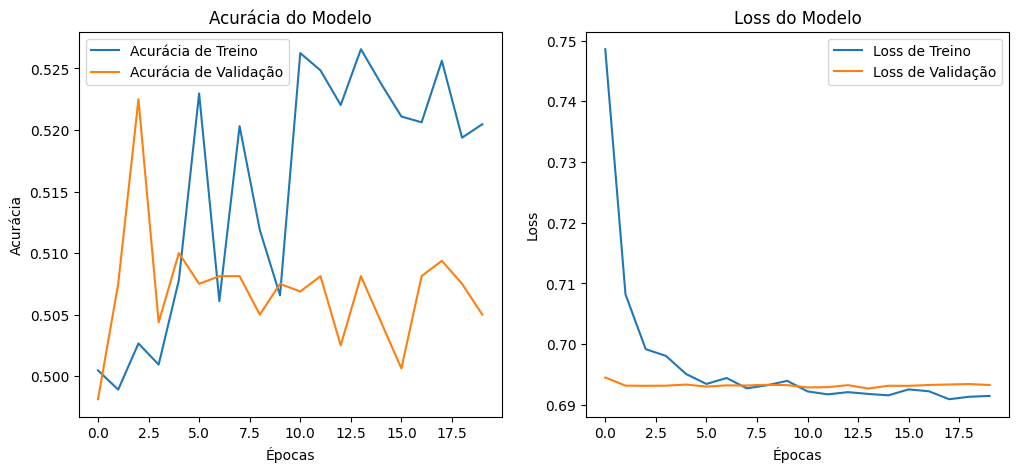

In [24]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Acurácia do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss de Treino')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.title('Loss do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

Os resultados sugerem um forte caso de sobreajuste (overfitting), onde o modelo memoriza os dados de treino em vez de aprender a lógica subjacente. Isso é evidenciado pela acurácia de treino significativamente maior do que a de validação e pela grande instabilidade das curvas de acurácia.

In [25]:
df_model = df_blood.copy()

df_model['created_at'] = pd.to_datetime(df_model['created_at'])

df_model['registration_year'] = df_model['created_at'].dt.year
df_model['registration_month'] = df_model['created_at'].dt.month
df_model['registration_day_of_week'] = df_model['created_at'].dt.dayofweek

df_model = df_model.drop(columns=['donor_id', 'name', 'email', 'password', 'contact_number', 'created_at'])

le = LabelEncoder()
df_model['availability'] = le.fit_transform(df_model['availability'])

df_model = pd.get_dummies(df_model, columns=['city', 'blood_group'], drop_first=True)

X = df_model.drop('availability', axis=1)
y = df_model['availability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Avaliação do Modelo XGBoost
Acurácia: 0.5005
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.50      0.47      0.48       992
           1       0.50      0.53      0.52      1008

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:31:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


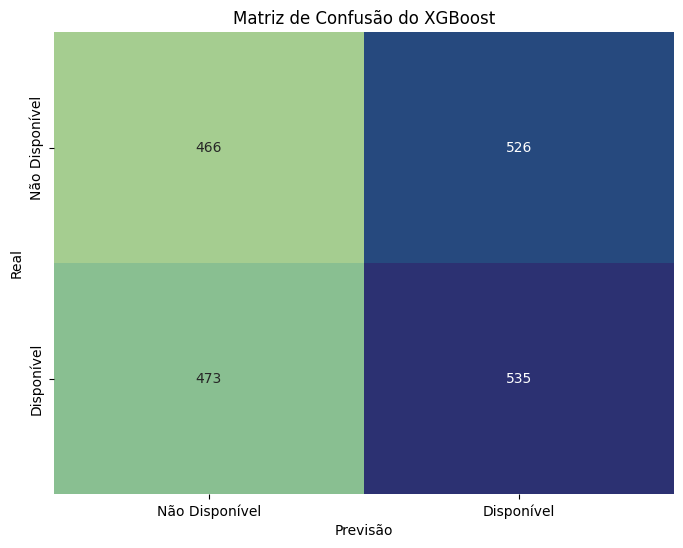

In [26]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print("Avaliação do Modelo XGBoost")
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='crest', cbar=False,
            xticklabels=['Não Disponível', 'Disponível'],
            yticklabels=['Não Disponível', 'Disponível'])
plt.title('Matriz de Confusão do XGBoost')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

O modelo não é totalmente confiável para a tarefa de prever a disponibilidade de doadores. 

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

Epoch 1/100


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4997 - loss: 0.7044 - val_accuracy: 0.5138 - val_loss: 0.6929
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4806 - loss: 0.6998 - val_accuracy: 0.5238 - val_loss: 0.6930
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5155 - loss: 0.6924 - val_accuracy: 0.5138 - val_loss: 0.6926
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4981 - loss: 0.6949 - val_accuracy: 0.4969 - val_loss: 0.6931
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5152 - loss: 0.6918 - val_accuracy: 0.5100 - val_loss: 0.6931
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5148 - loss: 0.6922 - val_accuracy: 0.4994 - val_loss: 0.6940
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5177 - loss: 0.6920 - val_accuracy: 0.4994 - val_loss: 0.6928
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5303 - loss: 0.6918 - val_accuracy: 0.5113

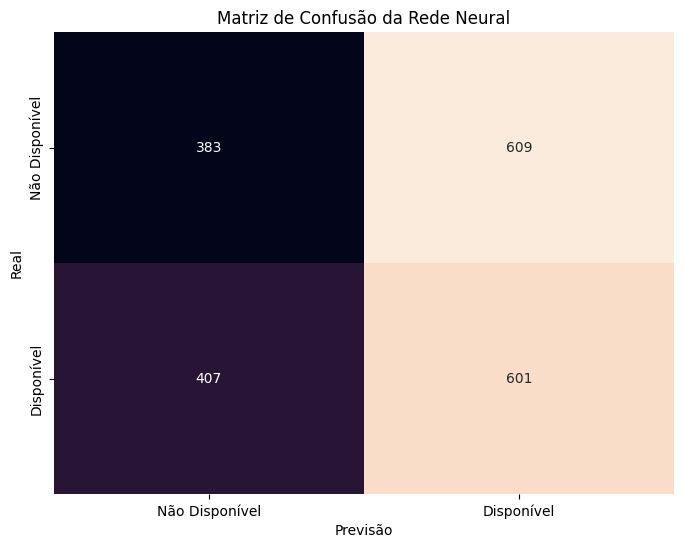

In [28]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_nn_tuned = Sequential()
model_nn_tuned.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model_nn_tuned.add(Dropout(0.3))
model_nn_tuned.add(Dense(64, activation='relu'))
model_nn_tuned.add(Dropout(0.3))
model_nn_tuned.add(Dense(32, activation='relu'))
model_nn_tuned.add(Dropout(0.3))
model_nn_tuned.add(Dense(1, activation='sigmoid'))

model_nn_tuned.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_tuned = model_nn_tuned.fit(X_train_scaled, y_train,
                                    epochs=100,
                                    batch_size=64,
                                    validation_split=0.2,
                                    callbacks=[early_stopping],
                                    verbose=1)

loss, accuracy = model_nn_tuned.evaluate(X_test_scaled, y_test, verbose=0)
print("Avaliação da Rede Neural Otimizada")
print(f"Acurácia no conjunto de teste: {accuracy:.4f}")

y_pred_nn_prob = model_nn_tuned.predict(X_test_scaled)
y_pred_nn = np.round(y_pred_nn_prob).flatten()

print("Relatório de Classificação da Rede Neural Otimizada:")
print(classification_report(y_test, y_pred_nn))

cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='rocket', cbar=False,
            xticklabels=['Não Disponível', 'Disponível'],
            yticklabels=['Não Disponível', 'Disponível'])
plt.title('Matriz de Confusão da Rede Neural')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

Essa performance sugere que a rede neural não está aprendendo as características que distinguem doadores disponíveis dos não disponíveis.Os resultados de acertos e erros são muito próximos, indicando que o modelo tem dificuldades para fazer previsões confiáveis.

# Conclusão

Ao histórico de doação, como number_of_donation (número de doações) e pints_donated (litros doados), são os preditores mais fortes para a availability (disponibilidade) do doador. Isso sugere que a fidelidade e o engajamento passado de um doador são os indicadores mais confiáveis de sua disponibilidade futura. O months_since_first_donation: a primeira doação e o número de doações mostra que doadores com um histórico mais longo tendem a ser mais experientes e, potencialmente, mais engajados. Essa feature é crucial para entender o "ciclo de vida" do doador.

# Limitações

O conjunto de dados, embora interessante, tem algumas limitações. A ausência de colunas mencionadas na descrição original (como hemoglobin, age e weight) foi um ponto de atenção.

# **Nathália Sorg**